In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path

In [2]:
base_dir = Path("experiment4_testing/layers_7_14_21/max_chars750000")
results = {}
for folder in base_dir.iterdir():
    if folder.is_dir() and folder.name.startswith("pca_comps_"):
        result_file = folder / "experimental_results.json"
        if result_file.exists():
            with open(result_file) as f:
                data = json.load(f)
                I = data["pca_comps_I"]
                O = data["pca_comps_O"]
                results[(I, O)] = data

In [3]:
I_values = sorted(set(k[0] for k in results.keys()))
O_values = sorted(set(k[1] for k in results.keys()))

perplexity_diff = np.full((len(I_values), len(O_values)), np.nan)

for i, I in enumerate(I_values):
    for j, O in enumerate(O_values):
        if (I, O) in results:
            data = results[(I, O)]
            baseline = data["baseline_perplexity_val"]
            intervened = data["intervened_perplexity_val"]
            perplexity_diff[i, j] = intervened - baseline

In [4]:
baseline

10.618621775614777

In [5]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

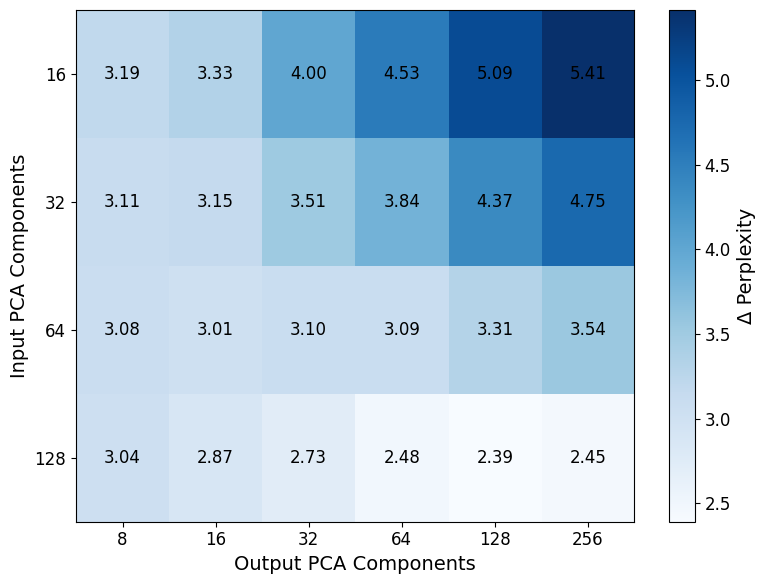

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(perplexity_diff, aspect='auto', cmap = 'Blues')
ax.set_xticks(range(len(O_values)))
ax.set_yticks(range(len(I_values)))
ax.set_xticklabels(O_values)
ax.set_yticklabels(I_values)
ax.set_xlabel('Output PCA Components')
ax.set_ylabel('Input PCA Components')
# ax.set_title('Perplexity Difference on Validation (Intervened - Baseline)')
for i in range(len(I_values)):
    for j in range(len(O_values)):
        if not np.isnan(perplexity_diff[i, j]):
            text = ax.text(j, i, f'{perplexity_diff[i, j]:.2f}', 
                           ha='center', va='center', color='black')
plt.colorbar(im, ax=ax, label='Δ Perplexity')
plt.tight_layout()
plt.savefig('figures/pca_results.png', dpi = 300)
plt.show()

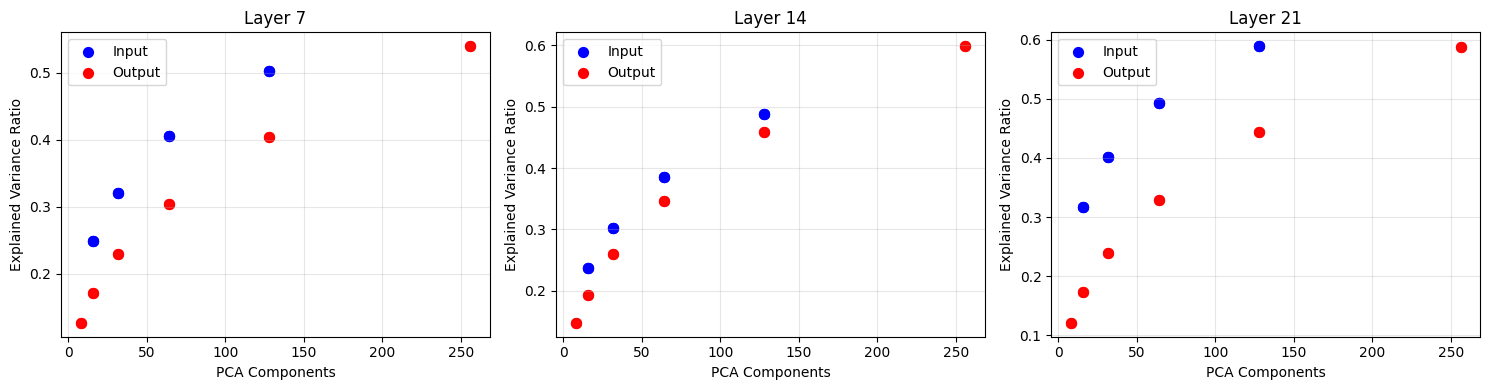

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
layers = [7, 14, 21]

for idx, layer in enumerate(layers):
    ax = axes[idx]
    for I, O in results.keys():
        data = results[(I, O)]
        layer_key = f"pca_layer{layer}"
        if layer_key in data:
            ax.scatter(I, data[layer_key]["input_explained_var_ratio"], 
                       color='blue', alpha=0.6, s=50)
            ax.scatter(O, data[layer_key]["output_explained_var_ratio"], 
                       color='red', alpha=0.6, s=50)
    
    ax.scatter([], [], color='blue', label='Input', s=50)
    ax.scatter([], [], color='red', label='Output', s=50)
    ax.set_xlabel('PCA Components')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title(f'Layer {layer}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()